# Movie Recommendation System

## Exploratory Data Analysis (EDA)

Dataset: MovieLens Latest Small Dataset

This notebook explores movie ratings, genres, user behavior, and movie popularity to prepare for building a recommendation system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [3]:
print("Movies Dataset")
display(movies.head())

print("\nRatings Dataset")
display(ratings.head())

Movies Dataset


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings Dataset


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
print("Movies Missing Values")
print(movies.isnull().sum())

print("\nRatings Missing Values")
print(ratings.isnull().sum())

Movies Missing Values
movieId    0
title      0
genres     0
dtype: int64

Ratings Missing Values
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


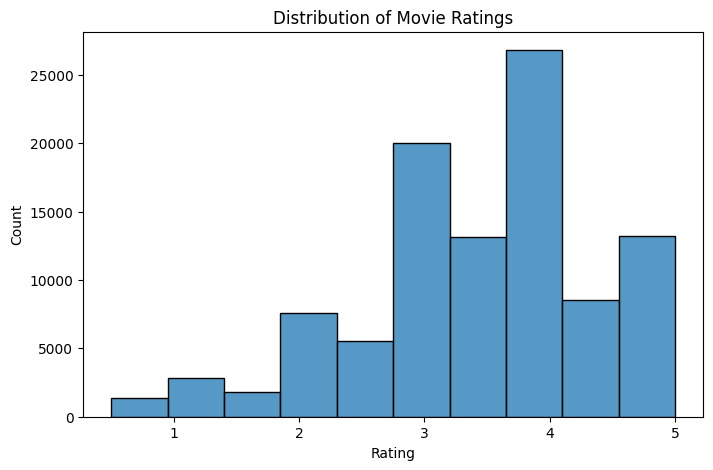

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(ratings["rating"], bins=10)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [6]:
movie_ratings = ratings.groupby("movieId").size()

top_movies = movie_ratings.sort_values(ascending=False).head(10)

top_movies = pd.DataFrame(top_movies).reset_index()
top_movies.columns = ["movieId", "rating_count"]

top_movies = top_movies.merge(movies, on="movieId")

top_movies[["title", "rating_count"]]

,title,rating_count
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


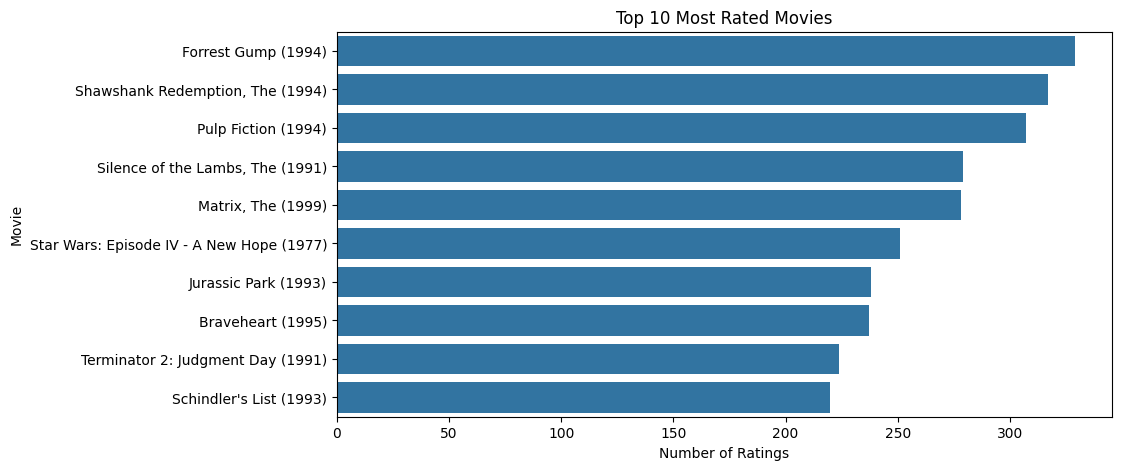

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_movies,
    x="rating_count",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()